In [2]:
import sys
from pathlib import Path


current_directory = Path.cwd()

repo_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


from temperature_profile import sample_course_points


course_path = (
    repo_root
    / "data"
    / "processed"
    / "peachtree_course.geojson"
)

route_samples = sample_course_points(
    course_path=course_path,
    spacing_m=100,
)


print("Repository root:", repo_root)
print("Course exists:", course_path.exists())
print("Result type:", type(route_samples).__name__)
print("Sample count:", len(route_samples))
print("Output CRS:", route_samples.crs)
print("Metric CRS used:", route_samples.attrs["metric_crs"])
print(
    "Course length:",
    f"{route_samples.attrs['course_length_m']:,.2f} m",
)
print(
    "First distance:",
    f"{route_samples['distance_m'].iloc[0]:,.2f} m",
)
print(
    "Final distance:",
    f"{route_samples['distance_m'].iloc[-1]:,.2f} m",
)

Repository root: c:\RaceGuard
Course exists: True
Result type: GeoDataFrame
Sample count: 101
Output CRS: EPSG:4326
Metric CRS used: EPSG:32616
Course length: 9,990.25 m
First distance: 0.00 m
Final distance: 9,990.25 m


In [3]:
route_samples

,sample_id,distance_m,distance_km,latitude,longitude,geometry
0,0,0.000000,0.00000,33.849322,-84.363280,POINT (-84.36328 33.84932)
1,1,100.000000,0.10000,33.849149,-84.364117,POINT (-84.36412 33.84915)
2,2,200.000000,0.20000,33.849020,-84.365165,POINT (-84.36517 33.84902)
3,3,300.000000,0.30000,33.848809,-84.366187,POINT (-84.36619 33.84881)
4,4,400.000000,0.40000,33.848186,-84.366958,POINT (-84.36696 33.84819)
...,...,...,...,...,...,...
96,96,9600.000000,9.60000,33.781795,-84.378879,POINT (-84.37888 33.78179)
97,97,9700.000000,9.70000,33.781794,-84.377800,POINT (-84.3778 33.78179)
98,98,9800.000000,9.80000,33.781793,-84.376720,POINT (-84.37672 33.78179)
99,99,9900.000000,9.90000,33.781793,-84.375641,POINT (-84.37564 33.78179)


In [4]:
import math


spacing = (
    route_samples["distance_m"]
    .diff()
    .dropna()
)

first_sample = route_samples.iloc[0]
final_sample = route_samples.iloc[-1]

expected_start = {
    "latitude": 33.849322,
    "longitude": -84.363280,
}

expected_finish = {
    "latitude": 33.781792,
    "longitude": -84.374667,
}


checks = {
    "101 samples created": (
        len(route_samples) == 101
    ),
    "all geometries are points": (
        route_samples.geometry.geom_type
        .eq("Point")
        .all()
    ),
    "no coordinates are missing": (
        route_samples[
            ["latitude", "longitude"]
        ]
        .notna()
        .all()
        .all()
    ),
    "distances increase strictly": (
        spacing.gt(0).all()
    ),
    "regular intervals are 100 m": all(
        math.isclose(
            interval,
            100.0,
            abs_tol=1e-6,
        )
        for interval in spacing.iloc[:-1]
    ),
    "final interval is between 0 and 100 m": (
        0 < spacing.iloc[-1] <= 100
    ),
    "first distance is zero": math.isclose(
        first_sample["distance_m"],
        0.0,
        abs_tol=1e-6,
    ),
    "final distance equals course length": (
        math.isclose(
            final_sample["distance_m"],
            route_samples.attrs[
                "course_length_m"
            ],
            abs_tol=1e-6,
        )
    ),
    "start coordinate matches course": (
        math.isclose(
            first_sample["latitude"],
            expected_start["latitude"],
            abs_tol=1e-6,
        )
        and math.isclose(
            first_sample["longitude"],
            expected_start["longitude"],
            abs_tol=1e-6,
        )
    ),
    "finish coordinate matches course": (
        math.isclose(
            final_sample["latitude"],
            expected_finish["latitude"],
            abs_tol=1e-6,
        )
        and math.isclose(
            final_sample["longitude"],
            expected_finish["longitude"],
            abs_tol=1e-6,
        )
    ),
}


for check_name, passed in checks.items():
    print(f"{check_name}: {passed}")


print()
print(
    "Final interval:",
    f"{spacing.iloc[-1]:.2f} m",
)

print()
print("Start and finish samples:")

print(
    route_samples.iloc[
        [0, -1]
    ][
        [
            "sample_id",
            "distance_m",
            "distance_km",
            "latitude",
            "longitude",
        ]
    ].to_string(index=False)
)


if not all(checks.values()):
    raise ValueError(
        "Route sampling failed numeric validation."
    )

101 samples created: True
all geometries are points: True
no coordinates are missing: True
distances increase strictly: True
regular intervals are 100 m: True
final interval is between 0 and 100 m: True
first distance is zero: True
final distance equals course length: True
start coordinate matches course: True
finish coordinate matches course: True

Final interval: 90.25 m

Start and finish samples:
 sample_id  distance_m  distance_km  latitude  longitude
         0    0.000000      0.00000 33.849322 -84.363280
       100 9990.249582      9.99025 33.781792 -84.374667


In [5]:
import folium
import geopandas as gpd


course = gpd.read_file(
    course_path
).to_crs("EPSG:4326")

middle_sample = route_samples.iloc[
    len(route_samples) // 2
]

route_map = folium.Map(
    location=[
        middle_sample["latitude"],
        middle_sample["longitude"],
    ],
    zoom_start=13,
    tiles="OpenStreetMap",
)


# Draw the original validated course.
folium.GeoJson(
    course.__geo_interface__,
    name="Validated course",
    style_function=lambda feature: {
        "color": "#2563EB",
        "weight": 5,
        "opacity": 0.8,
    },
    tooltip="Validated Peachtree course",
).add_to(route_map)


# Draw every generated 100-metre sample.
for _, sample in route_samples.iterrows():
    folium.CircleMarker(
        location=[
            sample["latitude"],
            sample["longitude"],
        ],
        radius=3,
        color="#111827",
        fill=True,
        fill_color="#FBBF24",
        fill_opacity=0.9,
        weight=1,
        popup=(
            f"Sample {int(sample['sample_id'])}<br>"
            f"Distance: {sample['distance_km']:.3f} km"
        ),
    ).add_to(route_map)


# Emphasize the start and finish.
start_sample = route_samples.iloc[0]
finish_sample = route_samples.iloc[-1]

folium.Marker(
    location=[
        start_sample["latitude"],
        start_sample["longitude"],
    ],
    tooltip="Start",
    popup="Course start — 0.000 km",
    icon=folium.Icon(
        color="green",
        icon="play",
    ),
).add_to(route_map)

folium.Marker(
    location=[
        finish_sample["latitude"],
        finish_sample["longitude"],
    ],
    tooltip="Finish",
    popup=(
        "Course finish — "
        f"{finish_sample['distance_km']:.3f} km"
    ),
    icon=folium.Icon(
        color="red",
        icon="flag",
    ),
).add_to(route_map)


# Adjust the view so the complete course is visible.
min_lon, min_lat, max_lon, max_lat = (
    course.total_bounds
)

route_map.fit_bounds(
    [
        [min_lat, min_lon],
        [max_lat, max_lon],
    ]
)

folium.LayerControl().add_to(route_map)

route_map

In [6]:
import importlib

import temperature_profile


importlib.reload(temperature_profile)

heatmap_path = (
    repo_root
    / "data"
    / "raw"
    / "fortyguard"
    / "peachtree_heatmap_2026_07_04_0900_g100.json"
)

heatmap_tiles = (
    temperature_profile.load_heatmap_tiles(
        heatmap_path
    )
)


print(
    "Result type:",
    type(heatmap_tiles).__name__,
)

print(
    "Tile count:",
    len(heatmap_tiles),
)

print(
    "CRS:",
    heatmap_tiles.crs,
)

print(
    "Columns:",
    sorted(heatmap_tiles.columns),
)

print(
    "Geometry types:",
    sorted(
        heatmap_tiles.geometry
        .geom_type
        .unique()
    ),
)

print(
    "Unique tile IDs:",
    heatmap_tiles["tile_id"].is_unique,
)

print(
    "All geometries valid:",
    heatmap_tiles.geometry.is_valid.all(),
)

Result type: GeoDataFrame
Tile count: 381
CRS: EPSG:4326
Columns: ['average_temperature', 'geometry', 'max_temperature', 'min_temperature', 'tile_id']
Geometry types: ['Polygon']
Unique tile IDs: True
All geometries valid: True


In [7]:
importlib.reload(temperature_profile)

profile = temperature_profile.match_course_points_to_heatmap(
    route_samples,
    heatmap_tiles,
)

print("Profile rows:", len(profile))
print("Missing tiles:", profile["tile_id"].isna().sum())
print("Missing temperatures:", profile["average_temperature"].isna().sum())
print("Duplicate course indices:", profile.index.duplicated().sum())
print("Match methods:")
print(profile["match_method"].value_counts())
print("Maximum fallback distance:", profile["tile_distance_m"].max())

Profile rows: 101
Missing tiles: 0
Missing temperatures: 0
Duplicate course indices: 0
Match methods:
match_method
intersects    96
nearest        5
Name: count, dtype: int64
Maximum fallback distance: 32.472187866571765


Minimum route temperature: 26.6450°C
Maximum route temperature: 27.3627°C
Route temperature range: 0.7177°C
Largest change between consecutive samples: 0.0676°C
Largest change ends at: 3.1 km

Nearest-tile fallback samples:
 distance_km  tile_id  average_temperature  tile_distance_m
         5.8      152              27.0413         0.917807
         5.9      150              27.0665        20.875441
         6.0      148              27.1057        31.539139
         6.1      146              27.1541        32.472188
         6.2      144              27.2066         6.130965


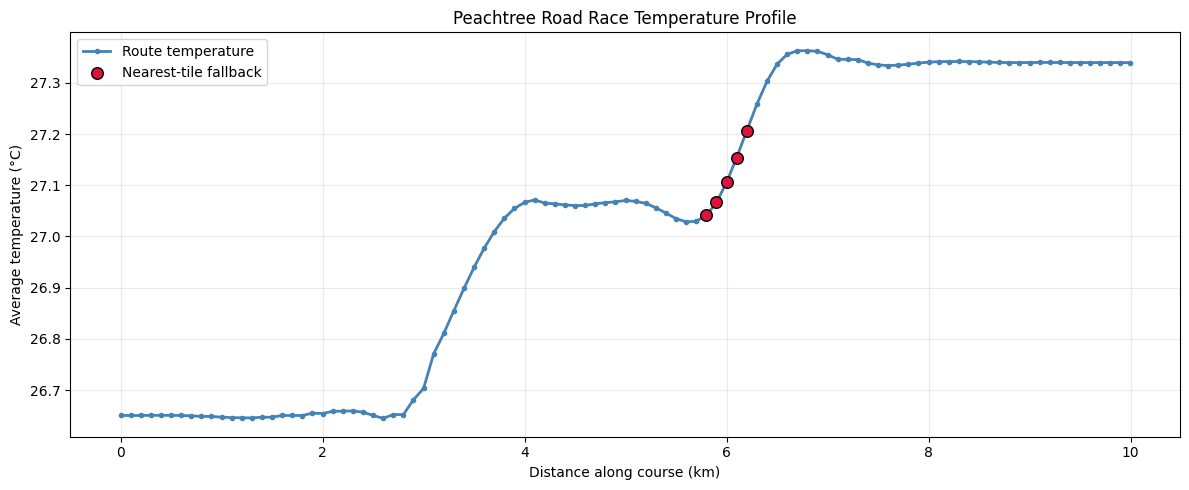

In [76]:
import matplotlib.pyplot as plt


profile_for_plot = profile.sort_values(
    "distance_m"
).copy()

nearest_mask = (
    profile_for_plot["match_method"] == "nearest"
)

temperature_changes = (
    profile_for_plot["average_temperature"]
    .diff()
    .abs()
)

largest_jump_index = temperature_changes.idxmax()


print(
    f"Minimum route temperature: "
    f"{profile_for_plot['average_temperature'].min():.4f}°C"
)

print(
    f"Maximum route temperature: "
    f"{profile_for_plot['average_temperature'].max():.4f}°C"
)

print(
    f"Route temperature range: "
    f"{profile_for_plot['average_temperature'].max() - profile_for_plot['average_temperature'].min():.4f}°C"
)

print(
    f"Largest change between consecutive samples: "
    f"{temperature_changes.loc[largest_jump_index]:.4f}°C"
)

print(
    f"Largest change ends at: "
    f"{profile_for_plot.loc[largest_jump_index, 'distance_km']:.1f} km"
)

print("\nNearest-tile fallback samples:")

print(
    profile_for_plot.loc[
        nearest_mask,
        [
            "distance_km",
            "tile_id",
            "average_temperature",
            "tile_distance_m",
        ],
    ].to_string(index=False)
)


fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    profile_for_plot["distance_km"],
    profile_for_plot["average_temperature"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Route temperature",
)

ax.scatter(
    profile_for_plot.loc[
        nearest_mask,
        "distance_km",
    ],
    profile_for_plot.loc[
        nearest_mask,
        "average_temperature",
    ],
    color="crimson",
    edgecolor="black",
    s=70,
    zorder=3,
    label="Nearest-tile fallback",
)

ax.set_title(
    "Peachtree Road Race Temperature Profile"
)

ax.set_xlabel(
    "Distance along course (km)"
)

ax.set_ylabel(
    "Average temperature (°C)"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

In [8]:
from geopandas.testing import assert_geodataframe_equal

importlib.reload(temperature_profile)
wrapper_profile = temperature_profile.build_route_temperature_profile(
    course_path,
    heatmap_path,
)

assert_geodataframe_equal(
    wrapper_profile,
    profile,
)

print("End-to-end route-temperature profile test passed.")

End-to-end route-temperature profile test passed.


In [9]:
import pandas as pd


stations_path = (
    repo_root
    / "data"
    / "processed"
    / "peachtree_stations.csv"
)

print("Station file exists:", stations_path.is_file())

stations = pd.read_csv(stations_path)

print("Row count:", len(stations))
print("Columns:", stations.columns.tolist())

print("\nData types:")
print(stations.dtypes)

print("\nMissing values:")
print(stations.isna().sum())

print("\nFully duplicated rows:", stations.duplicated().sum())

print("\nStation data:")
print(stations.to_string(index=False))

Station file exists: True
Row count: 5
Columns: ['station_id', 'official_mile', 'baseline_distance_km', 'side_count', 'has_water', 'has_restrooms', 'has_first_aid', 'position_uncertainty_m', 'source_url', 'longitude', 'latitude']

Data types:
station_id                 object
official_mile               int64
baseline_distance_km      float64
side_count                  int64
has_water                    bool
has_restrooms                bool
has_first_aid                bool
position_uncertainty_m    float64
source_url                 object
longitude                 float64
latitude                  float64
dtype: object

Missing values:
station_id                0
official_mile             0
baseline_distance_km      0
side_count                0
has_water                 0
has_restrooms             0
has_first_aid             0
position_uncertainty_m    0
source_url                0
longitude                 0
latitude                  0
dtype: int64

Fully duplicated rows: 0

Stat

In [10]:
import geopandas as gpd
import pandas as pd


# Load the validated course line.
course_gdf = gpd.read_file(course_path)

if course_gdf.crs is None:
    raise ValueError("The course GeoJSON has no CRS.")

if len(course_gdf) != 1:
    raise ValueError(
        f"Expected one course feature, found {len(course_gdf)}."
    )

if course_gdf.geometry.iloc[0].geom_type != "LineString":
    raise ValueError(
        "Expected the course geometry to be a LineString."
    )


# Select an appropriate metre-based CRS for the Atlanta course.
metric_crs = course_gdf.estimate_utm_crs()

if metric_crs is None:
    raise ValueError("Could not determine a metric CRS.")


# Project the course so interpolation distances are measured in metres.
course_metric = course_gdf.to_crs(metric_crs)
course_line_metric = course_metric.geometry.iloc[0]
course_length_m = course_line_metric.length


# Convert the source longitude/latitude columns into Point geometries.
source_points = gpd.GeoSeries(
    gpd.points_from_xy(
        stations["longitude"],
        stations["latitude"],
    ),
    index=stations.index,
    crs="EPSG:4326",
)

source_points_metric = source_points.to_crs(metric_crs)


# Convert the official race distances from kilometres to metres.
baseline_distances_m = (
    stations["baseline_distance_km"] * 1000
)

if (baseline_distances_m < 0).any():
    raise ValueError(
        "A station has a negative baseline distance."
    )

if (baseline_distances_m > course_length_m).any():
    raise ValueError(
        "A station lies beyond the end of the course."
    )


# Derive each station's canonical location directly from its official
# distance along the course line.
canonical_points_metric = gpd.GeoSeries(
    [
        course_line_metric.interpolate(distance_m)
        for distance_m in baseline_distances_m
    ],
    index=stations.index,
    crs=metric_crs,
)


# Measure the straight-line disagreement between the supplied coordinate
# and the canonical mile-based course point.
source_coordinate_offsets_m = (
    source_points_metric.distance(
        canonical_points_metric
    )
)


station_validation = stations[
    [
        "station_id",
        "official_mile",
        "baseline_distance_km",
        "position_uncertainty_m",
    ]
].copy()

station_validation["baseline_distance_m"] = (
    baseline_distances_m
)

station_validation["source_coordinate_offset_m"] = (
    source_coordinate_offsets_m
)

station_validation["within_declared_uncertainty"] = (
    station_validation["source_coordinate_offset_m"]
    <= station_validation["position_uncertainty_m"]
)


print("Metric CRS:", metric_crs)
print(f"Course length: {course_length_m:,.2f} m")

print("\nStation-coordinate validation:")

print(
    station_validation[
        [
            "station_id",
            "official_mile",
            "baseline_distance_km",
            "source_coordinate_offset_m",
            "position_uncertainty_m",
            "within_declared_uncertainty",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.2f}",
    )
)

print(
    "\nStations within declared uncertainty:",
    int(
        station_validation[
            "within_declared_uncertainty"
        ].sum()
    ),
    "of",
    len(station_validation),
)

Metric CRS: EPSG:32616
Course length: 9,990.25 m

Station-coordinate validation:
station_id  official_mile  baseline_distance_km  source_coordinate_offset_m  position_uncertainty_m  within_declared_uncertainty
     AID_1              1                  1.61                        0.00                  200.00                         True
     AID_2              2                  3.22                        0.00                  200.00                         True
     AID_3              3                  4.83                        0.00                  200.00                         True
     AID_4              4                  6.44                        0.00                  200.00                         True
     AID_5              5                  8.05                        0.00                  200.00                         True

Stations within declared uncertainty: 5 of 5


In [80]:
import json

from datetime import date, timedelta
from dotenv import load_dotenv
from fortyguard import FortyGuardClient


load_dotenv(repo_root / ".env")

client = FortyGuardClient()


# Use the course sample closest to 5 km.
profile_wgs84 = profile.to_crs("EPSG:4326")

target_index = (
    profile_wgs84["distance_km"] - 5.0
).abs().idxmin()

target_sample = profile_wgs84.loc[target_index]

request_latitude = float(target_sample.geometry.y)
request_longitude = float(target_sample.geometry.x)
request_temperature = float(
    target_sample["average_temperature"]
)

analysis_parameters = [
    "wet_bulb_temperature_celsius",
    "relative_humidity_percent",
    "apparent_temperature_celsius",
]


cache_path = (
    repo_root
    / "data"
    / "raw"
    / "fortyguard"
    / "peachtree_env_params_2026_07_04_0900_km5.json"
)

cache_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


print("Calibration location:")
print(f"  Course distance: {target_sample['distance_km']:.1f} km")
print(f"  Latitude:        {request_latitude:.6f}")
print(f"  Longitude:       {request_longitude:.6f}")
print(f"  Temperature:     {request_temperature:.4f}°C")
print(f"  Cache path:      {cache_path}")


credit_delta = None

if cache_path.is_file():
    print("\nUsing existing cached response. No paid request made.")

    with cache_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        response = json.load(file)

else:
    usage_end_date = date.today().isoformat()

    usage_start_date = (
        date.today() - timedelta(days=30)
    ).isoformat()

    usage_before = client.fetch_api_key_custom_usage(
        start_date=usage_start_date,
        end_date=usage_end_date,
    )

    credits_before = usage_before.get(
        "total_credits_used"
    )

    print("\nNo cache found.")
    print("Submitting one paid environmental-parameters request...")

    response = client.environmental_parameters(
        latitude=request_latitude,
        longitude=request_longitude,
        temperature=request_temperature,
        start_date="2026-07-04",
        start_time="09:00",
        filter_type=1,
        analysis=analysis_parameters,
    )

    if not isinstance(response, dict):
        raise ValueError(
            "Environmental response is not a dictionary."
        )

    if not isinstance(response.get("result"), dict):
        raise ValueError(
            "Environmental response has no valid result."
        )

    with cache_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            response,
            file,
            indent=2,
        )

    print("Response cached successfully.")

    usage_after = client.fetch_api_key_custom_usage(
        start_date=usage_start_date,
        end_date=usage_end_date,
    )

    credits_after = usage_after.get(
        "total_credits_used"
    )

    if (
        credits_before is not None
        and credits_after is not None
    ):
        credit_delta = (
            credits_after - credits_before
        )


result = response.get("result")

if not isinstance(result, dict):
    raise ValueError(
        "Cached response has no valid result."
    )

locations = result.get("locations")

if not isinstance(locations, list) or not locations:
    raise ValueError(
        "Environmental response contains no locations."
    )

location = locations[0]
parameters = location.get("parameters")

if not isinstance(parameters, dict):
    raise ValueError(
        "Environmental response contains no parameter dictionary."
    )

missing_parameters = [
    parameter
    for parameter in analysis_parameters
    if parameter not in parameters
]

if missing_parameters:
    raise ValueError(
        f"Response is missing parameters: {missing_parameters}"
    )


print("\nActivity ID:", response.get("activity_id"))

print("\nReturned environmental parameters:")

for parameter in analysis_parameters:
    print(
        f"  {parameter}: "
        f"{parameters.get(parameter)}"
    )

if credit_delta is not None:
    print(
        "\nCredits consumed by calibration request:",
        credit_delta,
    )
else:
    print(
        "\nCredit delta unavailable because the response "
        "was cached or usage totals were unavailable."
    )

Calibration location:
  Course distance: 5.0 km
  Latitude:        33.815333
  Longitude:       -84.391415
  Temperature:     27.0703°C
  Cache path:      c:\RaceGuard\data\raw\fortyguard\peachtree_env_params_2026_07_04_0900_km5.json

No cache found.
Submitting one paid environmental-parameters request...
Submitted -> activity_id=16fac49b-2c2b-40ff-bae5-eaea3aab5c32
  status: processing
  status: completed
Done.
Response cached successfully.

Activity ID: 16fac49b-2c2b-40ff-bae5-eaea3aab5c32

Returned environmental parameters:
  wet_bulb_temperature_celsius: [23.9]
  relative_humidity_percent: [55.2]
  apparent_temperature_celsius: [34.8]

Credits consumed by calibration request: 2900


In [11]:
import json
from pprint import pprint

cache_path = (
    repo_root
    / "data"
    / "raw"
    / "fortyguard"
    / "peachtree_env_params_2026_07_04_0900_km5.json"
)

if not cache_path.is_file():
    raise FileNotFoundError(f"Cached response not found: {cache_path}")

with cache_path.open("r", encoding="utf-8") as file:
    payload = json.load(file)

result = payload.get("result")

if not isinstance(result, dict):
    raise ValueError("The cached response has no valid 'result' object.")

locations = result.get("locations")

if not isinstance(locations, list) or not locations:
    raise ValueError("The cached response contains no location results.")

location = locations[0]

print("Top-level response fields:")
print(sorted(payload.keys()))

print("\nResult fields:")
print(sorted(result.keys()))

print("\nMetadata:")
pprint(result.get("metadata", {}), sort_dicts=False)

print("\nLocation fields:")
print(sorted(location.keys()))

print("\nLocation inputs:")
for field in ("lat", "lon", "elevation", "temperature"):
    print(f"  {field}: {location.get(field)}")

print("\nEnvironmental parameters:")
pprint(location.get("parameters", {}), sort_dicts=False)

print("\nSolar-irradiance data:")
pprint(location.get("solar_irradiance", {}), sort_dicts=False)

known_location_fields = {
    "lat",
    "lon",
    "elevation",
    "temperature",
    "parameters",
    "solar_irradiance",
}

additional_fields = {
    key: value
    for key, value in location.items()
    if key not in known_location_fields
}

print("\nAdditional location fields:")
if additional_fields:
    pprint(additional_fields, sort_dicts=False)
else:
    print("(none)")

Top-level response fields:
['activity_id', 'result']

Result fields:
['locations', 'metadata']

Metadata:
{'timezone': 'GMT-6',
 'timezone_offset_hours': -6,
 'time_range': {'start': '2026-07-04T09:00:00-06:00',
                'end': '2026-07-04T09:00:00-06:00',
                'interval': '1h',
                'count': 1},
 'timestamps': ['2026-07-04T09:00:00-06:00']}

Location fields:
['elevation', 'lat', 'lon', 'parameters', 'solar_irradiance', 'temperature']

Location inputs:
  lat: 33.815333099737686
  lon: -84.39141520661789
  elevation: 263.0
  temperature: 27.0703

Environmental parameters:
{'heat_index_celsius': [27.8],
 'apparent_temperature_celsius': [34.8],
 'relative_humidity_percent': [55.2],
 'precipitation_mm': [0.0],
 'cloud_cover_octas': [89.0],
 'wet_bulb_temperature_celsius': [23.9],
 'air_quality:idx': [73.3],
 'air_quality_pm2p5:idx': [73.3],
 'air_quality_pm10:idx': [21.9],
 'air_quality_no2:idx': [1.4],
 'aqi_us_co': [2.7],
 'air_quality_o3:idx': [23.5],
 'air_

In [12]:
testing_profile = profile.copy()
min_temp = testing_profile['average_temperature'].min()
testing_profile['temperature_excess'] = testing_profile['average_temperature'] - min_temp

In [13]:
testing_profile['temperature_excess']

0      0.0056
1      0.0056
2      0.0056
3      0.0058
4      0.0059
        ...  
96     0.6946
97     0.6945
98     0.6945
99     0.6945
100    0.6945
Name: temperature_excess, Length: 101, dtype: float64

In [14]:
testing_profile['heat_burden'] = testing_profile['temperature_excess'].cumsum().shift(1).fillna(0)

In [15]:
testing_profile.head()

,sample_id,distance_m,distance_km,latitude,longitude,geometry,tile_id,average_temperature,match_method,tile_distance_m,temperature_excess,heat_burden
0,0,0.0,0.0,33.849322,-84.363280,POINT (-84.36328 33.84932),370,26.6506,intersects,0.0,0.0056,0.0000
1,1,100.0,0.1,33.849149,-84.364117,POINT (-84.36412 33.84915),370,26.6506,intersects,0.0,0.0056,0.0056
2,2,200.0,0.2,33.849020,-84.365165,POINT (-84.36517 33.84902),369,26.6506,intersects,0.0,0.0056,0.0112
3,3,300.0,0.3,33.848809,-84.366187,POINT (-84.36619 33.84881),361,26.6508,intersects,0.0,0.0058,0.0168
4,4,400.0,0.4,33.848186,-84.366958,POINT (-84.36696 33.84819),360,26.6509,intersects,0.0,0.0059,0.0226


In [16]:
profile

,sample_id,distance_m,distance_km,latitude,longitude,geometry,tile_id,average_temperature,match_method,tile_distance_m
0,0,0.000000,0.00000,33.849322,-84.363280,POINT (-84.36328 33.84932),370,26.6506,intersects,0.0
1,1,100.000000,0.10000,33.849149,-84.364117,POINT (-84.36412 33.84915),370,26.6506,intersects,0.0
2,2,200.000000,0.20000,33.849020,-84.365165,POINT (-84.36517 33.84902),369,26.6506,intersects,0.0
3,3,300.000000,0.30000,33.848809,-84.366187,POINT (-84.36619 33.84881),361,26.6508,intersects,0.0
4,4,400.000000,0.40000,33.848186,-84.366958,POINT (-84.36696 33.84819),360,26.6509,intersects,0.0
...,...,...,...,...,...,...,...,...,...,...
96,96,9600.000000,9.60000,33.781795,-84.378879,POINT (-84.37888 33.78179),22,27.3396,intersects,0.0
97,97,9700.000000,9.70000,33.781794,-84.377800,POINT (-84.3778 33.78179),23,27.3395,intersects,0.0
98,98,9800.000000,9.80000,33.781793,-84.376720,POINT (-84.37672 33.78179),24,27.3395,intersects,0.0
99,99,9900.000000,9.90000,33.781793,-84.375641,POINT (-84.37564 33.78179),25,27.3395,intersects,0.0


In [17]:
import importlib
import numpy as np
import temperature_profile

importlib.reload(temperature_profile)

burden_profile = (
    temperature_profile.add_relative_heat_burden(profile)
)

required_columns = [
    "temperature_excess_c",
    "interval_distance_m",
    "interval_heat_burden_c_m",
    "cumulative_heat_burden_c_m",
]

assert len(burden_profile) == len(profile)

assert all(
    column in burden_profile.columns
    for column in required_columns
)

assert burden_profile[required_columns].notna().all().all()

assert np.isclose(
    burden_profile.iloc[0]["distance_m"],
    0.0,
)

assert np.isclose(
    burden_profile.iloc[0]["interval_distance_m"],
    0.0,
)

assert np.isclose(
    burden_profile.iloc[0]["interval_heat_burden_c_m"],
    0.0,
)

assert np.isclose(
    burden_profile.iloc[0]["cumulative_heat_burden_c_m"],
    0.0,
)

assert (
    burden_profile["temperature_excess_c"] >= 0
).all()

assert (
    burden_profile["interval_distance_m"].iloc[1:] > 0
).all()

assert (
    burden_profile["interval_heat_burden_c_m"] >= 0
).all()

assert (
    burden_profile["cumulative_heat_burden_c_m"]
    .diff()
    .dropna()
    >= 0
).all()

reference_temperature_c = (
    burden_profile["average_temperature"].min()
)

assert np.isclose(
    burden_profile["heat_reference_temperature_c"],
    reference_temperature_c,
).all()

manual_total_burden = 0.0

for index in range(1, len(burden_profile)):
    previous_row = burden_profile.iloc[index - 1]
    current_row = burden_profile.iloc[index]

    interval_distance_m = (
        current_row["distance_m"]
        - previous_row["distance_m"]
    )

    average_excess_c = (
        previous_row["temperature_excess_c"]
        + current_row["temperature_excess_c"]
    ) / 2

    manual_total_burden += (
        average_excess_c * interval_distance_m
    )

calculated_total_burden = burden_profile.iloc[-1][
    "cumulative_heat_burden_c_m"
]

assert np.isclose(
    calculated_total_burden,
    manual_total_burden,
)

print("Heat-burden validation passed.")
print(f"Rows: {len(burden_profile)}")
print(
    "Reference temperature: "
    f"{reference_temperature_c:.4f}°C"
)
print(
    "Final interval distance: "
    f"{burden_profile.iloc[-1]['interval_distance_m']:.2f} m"
)
print(
    "Total relative heat burden: "
    f"{calculated_total_burden:.2f} °C·m"
)

display(
    burden_profile[
        [
            "distance_km",
            "average_temperature",
            "temperature_excess_c",
            "interval_distance_m",
            "interval_heat_burden_c_m",
            "cumulative_heat_burden_c_m",
        ]
    ].head(10)
)

Heat-burden validation passed.
Rows: 101
Reference temperature: 26.6450°C
Final interval distance: 90.25 m
Total relative heat burden: 3856.45 °C·m


,distance_km,average_temperature,temperature_excess_c,interval_distance_m,interval_heat_burden_c_m,cumulative_heat_burden_c_m
0,0.0,26.6506,0.0056,0.0,0.000,0.000
1,0.1,26.6506,0.0056,100.0,0.560,0.560
2,0.2,26.6506,0.0056,100.0,0.560,1.120
3,0.3,26.6508,0.0058,100.0,0.570,1.690
4,0.4,26.6509,0.0059,100.0,0.585,2.275
5,0.5,26.6509,0.0059,100.0,0.590,2.865
6,0.6,26.6506,0.0056,100.0,0.575,3.440
7,0.7,26.6499,0.0049,100.0,0.525,3.965
8,0.8,26.6488,0.0038,100.0,0.435,4.400
9,0.9,26.6487,0.0037,100.0,0.375,4.775


In [18]:
importlib.reload(temperature_profile)

stations = pd.read_csv(
    repo_root
    / "data"
    / "processed"
    / "peachtree_stations.csv"
)

baseline_segments = (
    temperature_profile.evaluate_station_heat_segments(
        burden_profile=burden_profile,
        station_distances_m=(
            stations["baseline_distance_km"] * 1000
        ),
        station_ids=stations["station_id"],
    )
)


total_segment_burden = (
    baseline_segments["segment_heat_burden_c_m"].sum()
)

route_total_burden = burden_profile.iloc[-1][
    "cumulative_heat_burden_c_m"
]

assert np.isclose(
    total_segment_burden,
    route_total_burden,
)

print("Baseline segment evaluation passed.")
print(
    "Total reconstructed burden: "
    f"{total_segment_burden:.2f} °C·m"
)
print(
    "Maximum relief gap: "
    f"{baseline_segments['segment_distance_m'].max():.2f} m"
)
print(
    "Worst uninterrupted burden: "
    f"{baseline_segments['segment_heat_burden_c_m'].max():.2f} °C·m"
)

display(
    baseline_segments.round(
        {
            "start_distance_m": 2,
            "end_distance_m": 2,
            "segment_distance_m": 2,
            "segment_distance_km": 3,
            "segment_heat_burden_c_m": 2,
            "average_temperature_excess_c": 4,
        }
    )
)

Baseline segment evaluation passed.
Total reconstructed burden: 3856.45 °C·m
Maximum relief gap: 1943.53 m
Worst uninterrupted burden: 1350.94 °C·m


,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,segment_heat_burden_c_m,average_temperature_excess_c,is_worst_segment
0,1,START,AID_1,0.00,1609.34,1609.34,1.609,6.31,0.0039,False
1,2,AID_1,AID_2,1609.34,3218.69,1609.34,1.609,44.34,0.0276,False
2,3,AID_2,AID_3,3218.69,4828.03,1609.34,1.609,598.91,0.3721,False
3,4,AID_3,AID_4,4828.03,6437.38,1609.34,1.609,729.35,0.4532,False
4,5,AID_4,AID_5,6437.38,8046.72,1609.34,1.609,1126.60,0.7000,False
5,6,AID_5,FINISH,8046.72,9990.25,1943.53,1.944,1350.94,0.6951,True


In [29]:
import importlib
import station_optimizer

# Reload because station_optimizer.py has changed.
importlib.reload(station_optimizer)

baseline_station_positions = [
    1609.344,
    3218.688,
    4828.032,
    6437.376,
    8046.720,
]


optimized_stations, optimized_worst_burden = (
    station_optimizer.optimize_station_placement(
        profile=profile,
        baseline_station_positions=baseline_station_positions,
        min_gap_m=1000,
        max_gap_m=2000,
        max_movement_m=500,
    )
)

summary, baseline_segments, optimized_segments = (
    station_optimizer.evaluate_station_layouts(
        profile=profile,
        baseline_station_positions=baseline_station_positions,
        optimized_stations=optimized_stations,
    )
)

print("UI summary:")
for name, value in summary.items():
    print(f"{name}: {value:.2f}")

display(baseline_segments)
display(optimized_segments)


UI summary:
worst_exposure_reduction_percent: 18.21
baseline_worst_burden_share_percent: 35.03
optimized_worst_burden_share_percent: 28.65
baseline_worst_segment_distance_km: 1.94
optimized_worst_segment_distance_km: 1.59
maximum_station_movement_m: 481.31
total_station_movement_m: 2159.84
baseline_worst_burden_c_m: 1350.93
optimized_worst_burden_c_m: 1104.90


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,baseline,1,START,AID_1,0.000,1609.344000,1609.344000,1.609344,6.307794,0.163565,False
1,baseline,2,AID_1,AID_2,1609.344,3218.688000,1609.344000,1.609344,44.674616,1.158438,False
2,baseline,3,AID_2,AID_3,3218.688,4828.032000,1609.344000,1.609344,598.594291,15.521886,False
3,baseline,4,AID_3,AID_4,4828.032,6437.376000,1609.344000,1.609344,729.724018,18.922153,False
4,baseline,5,AID_4,AID_5,6437.376,8046.720000,1609.344000,1.609344,1126.224394,29.203631,False
5,baseline,6,AID_5,FINISH,8046.720,9990.249582,1943.529582,1.943530,1350.928223,35.030327,True


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,optimized,1,START,OPT_1,0.0,2000.000000,2000.000000,2.00000,9.140000,0.237005,False
1,optimized,2,OPT_1,OPT_2,2000.0,3700.000000,1700.000000,1.70000,173.935000,4.510232,False
2,optimized,3,OPT_2,OPT_3,3700.0,5300.000000,1600.000000,1.60000,665.430000,17.254973,False
3,optimized,4,OPT_3,OPT_4,5300.0,6900.000000,1600.000000,1.60000,858.045000,22.249589,False
4,optimized,5,OPT_4,OPT_5,6900.0,8400.000000,1500.000000,1.50000,1045.005000,27.097566,False
5,optimized,6,OPT_5,FINISH,8400.0,9990.249582,1590.249582,1.59025,1104.898335,28.650634,True


In [30]:
from pathlib import Path
import importlib
import sys


# Find the RaceGuard repository root whether the notebook is
# running from RaceGuard/ or RaceGuard/notebooks/.
project_root = Path.cwd()

if not (project_root / "temperature_profile.py").is_file():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


import temperature_profile
import station_optimizer

importlib.reload(temperature_profile)
importlib.reload(station_optimizer)


course_path = (
    project_root
    / "data"
    / "processed"
    / "bolder_boulder_course.geojson"
)

heatmap_matches = list(
    (
        project_root
        / "data"
        / "raw"
        / "fortyguard"
    ).glob("bolder_boulder_heatmap_*.json")
)

if not heatmap_matches:
    raise FileNotFoundError(
        "No cached BOLDERBoulder heatmap was found."
    )

heatmap_path = heatmap_matches[0]

print("Course:", course_path)
print("Cached heatmap:", heatmap_path)


# Build the temperature profile at 100 m intervals.
bolder_profile = (
    temperature_profile.build_route_temperature_profile(
        course_path=course_path,
        heatmap_path=heatmap_path,
        spacing_m=100,
        max_nearest_distance_m=50,
    )
)


# Add temperature excess and cumulative relative heat burden.
bolder_burden_profile = (
    station_optimizer.add_relative_heat_burden(
        bolder_profile
    )
)


course_length_m = float(
    bolder_burden_profile["distance_m"].iloc[-1]
)

minimum_temperature = float(
    bolder_burden_profile[
        "average_temperature"
    ].min()
)

maximum_temperature = float(
    bolder_burden_profile[
        "average_temperature"
    ].max()
)

total_burden = float(
    bolder_burden_profile[
        "cumulative_heat_burden_c_m"
    ].iloc[-1]
)


print()
print(f"Profile rows: {len(bolder_burden_profile)}")
print(f"Course length: {course_length_m:,.2f} m")
print(f"Minimum temperature: {minimum_temperature:.4f}°C")
print(f"Maximum temperature: {maximum_temperature:.4f}°C")
print(
    "Temperature range: "
    f"{maximum_temperature - minimum_temperature:.4f}°C"
)
print(
    "Total relative heat burden: "
    f"{total_burden:.2f} °C·m"
)

Course: c:\RaceGuard\data\processed\bolder_boulder_course.geojson
Cached heatmap: c:\RaceGuard\data\raw\fortyguard\bolder_boulder_heatmap_2026-05-25_0800_g100.json

Profile rows: 106
Course length: 10,463.24 m
Minimum temperature: 15.3087°C
Maximum temperature: 17.7065°C
Temperature range: 2.3978°C
Total relative heat burden: 9810.54 °C·m


In [32]:
# from pathlib import Path

# import folium
# import geopandas as gpd

# from shapely.geometry import mapping
# from shapely.ops import linemerge


# course_path = (
#     project_root
#     / "data"
#     / "processed"
#     / "bolder_boulder_course.geojson"
# )

# course = gpd.read_file(course_path).to_crs("EPSG:4326")

# course_line = course.geometry.iloc[0]

# if course_line.geom_type == "MultiLineString":
#     course_line = linemerge(course_line)

# if course_line.geom_type != "LineString":
#     raise ValueError(
#         f"Expected LineString, got {course_line.geom_type}"
#     )


# # Convert to a local metric projection for distance interpolation.
# metric_crs = course.estimate_utm_crs()

# course_line_metric = gpd.GeoSeries(
#     [course_line],
#     crs="EPSG:4326",
# ).to_crs(metric_crs).iloc[0]

# course_length_m = course_line_metric.length


# def metric_point_to_latlon(point):
#     point_wgs84 = gpd.GeoSeries(
#         [point],
#         crs=metric_crs,
#     ).to_crs("EPSG:4326").iloc[0]

#     return [point_wgs84.y, point_wgs84.x]


# bounds = course_line.bounds

# map_center = [
#     (bounds[1] + bounds[3]) / 2,
#     (bounds[0] + bounds[2]) / 2,
# ]

# inspection_map = folium.Map(
#     location=map_center,
#     zoom_start=13,
#     tiles="CartoDB positron",
# )


# # Current processed route.
# folium.GeoJson(
#     mapping(course_line),
#     name="Processed Bolder route",
#     style_function=lambda feature: {
#         "color": "#2563eb",
#         "weight": 5,
#         "opacity": 0.9,
#     },
# ).add_to(inspection_map)


# # Start and finish.
# start_point = course_line_metric.interpolate(0)
# finish_point = course_line_metric.interpolate(
#     course_length_m
# )

# folium.Marker(
#     metric_point_to_latlon(start_point),
#     tooltip="START",
#     icon=folium.Icon(color="green"),
# ).add_to(inspection_map)

# folium.Marker(
#     metric_point_to_latlon(finish_point),
#     tooltip=f"FINISH — {course_length_m / 1000:.3f} km",
#     icon=folium.Icon(color="red"),
# ).add_to(inspection_map)


# # Raw kilometre positions according to the current GeoJSON.
# for kilometre in range(
#     1,
#     int(course_length_m // 1000) + 1,
# ):
#     distance_m = kilometre * 1000

#     if distance_m >= course_length_m:
#         break

#     point = course_line_metric.interpolate(distance_m)

#     folium.CircleMarker(
#         metric_point_to_latlon(point),
#         radius=6,
#         color="#b45309",
#         fill=True,
#         fill_color="#f59e0b",
#         fill_opacity=1,
#         tooltip=f"Current geometry: {kilometre} km",
#     ).add_to(inspection_map)


# folium.LayerControl().add_to(inspection_map)

# output_path = (
#     project_root
#     / "data"
#     / "processed"
#     / "bolder_route_inspection.html"
# )

# inspection_map.save(output_path)

# print(f"Mapped course length: {course_length_m:,.2f} m")
# print(f"Saved map: {output_path}")

# inspection_map

In [33]:
OFFICIAL_BOLDER_LENGTH_M = 10_000.0

source_length_m = float(
    bolder_profile["distance_m"].iloc[-1]
)

distance_scale = (
    OFFICIAL_BOLDER_LENGTH_M / source_length_m
)

bolder_calibrated_profile = bolder_profile.copy()

# Preserve the original PlotARoute measurement for traceability.
bolder_calibrated_profile["source_distance_m"] = (
    bolder_calibrated_profile["distance_m"]
)

# Convert the distance axis to the official certified distance.
bolder_calibrated_profile["distance_m"] = (
    bolder_calibrated_profile["source_distance_m"]
    * distance_scale
)

bolder_calibrated_profile["distance_km"] = (
    bolder_calibrated_profile["distance_m"] / 1000
)

# The old cumulative burden used the uncalibrated distances,
# so it must be calculated again.
bolder_calibrated_profile = (
    station_optimizer.add_relative_heat_burden(
        bolder_calibrated_profile
    )
)

print(f"Source length: {source_length_m:,.2f} m")
print(f"Official length: {OFFICIAL_BOLDER_LENGTH_M:,.2f} m")
print(f"Distance scale: {distance_scale:.6f}")
print(
    "Calibrated final distance:",
    f"{bolder_calibrated_profile['distance_m'].iloc[-1]:,.2f} m",
)
print(
    "Recalculated total burden:",
    f"{bolder_calibrated_profile['cumulative_heat_burden_c_m'].iloc[-1]:.2f} °C·m",
)

Source length: 10,463.24 m
Official length: 10,000.00 m
Distance scale: 0.955727
Calibrated final distance: 10,000.00 m
Recalculated total burden: 9376.19 °C·m


In [34]:
import numpy as np


METRES_PER_MILE = 1609.344

bolder_baseline_station_positions = [
    2 * METRES_PER_MILE,
    3 * METRES_PER_MILE,
    4 * METRES_PER_MILE,
    5 * METRES_PER_MILE,
]


# Find the longest interval in the current Bolder layout.
baseline_boundaries = np.array(
    [
        0.0,
        *bolder_baseline_station_positions,
        OFFICIAL_BOLDER_LENGTH_M,
    ]
)

baseline_gaps = np.diff(baseline_boundaries)
bolder_baseline_max_gap_m = float(baseline_gaps.max())


print("Baseline station distances:")
print(bolder_baseline_station_positions)

print("Baseline interval distances:")
print(baseline_gaps)

print(
    "Current maximum interval:",
    f"{bolder_baseline_max_gap_m:,.2f} m",
)


bolder_optimized_stations, bolder_optimized_worst_burden = (
    station_optimizer.optimize_station_placement(
        profile=bolder_calibrated_profile,
        baseline_station_positions=(
            bolder_baseline_station_positions
        ),
        min_gap_m=1000,
        max_gap_m=bolder_baseline_max_gap_m,
        max_movement_m=500,
    )
)


(
    bolder_summary,
    bolder_baseline_segments,
    bolder_optimized_segments,
) = station_optimizer.evaluate_station_layouts(
    profile=bolder_calibrated_profile,
    baseline_station_positions=(
        bolder_baseline_station_positions
    ),
    optimized_stations=bolder_optimized_stations,
)


print()
print(
    "Optimized worst burden:",
    f"{bolder_optimized_worst_burden:.2f} °C·m",
)

print()
print("UI summary:")

for name, value in bolder_summary.items():
    print(f"{name}: {value:.2f}")


display(
    bolder_optimized_stations[
        [
            "station_id",
            "distance_m",
            "distance_km",
            "latitude",
            "longitude",
            "average_temperature",
            "baseline_distance_m",
            "movement_m",
        ]
    ]
)

display(bolder_baseline_segments)
display(bolder_optimized_segments)

Baseline station distances:
[3218.688, 4828.032, 6437.376, 8046.72]
Baseline interval distances:
[3218.688 1609.344 1609.344 1609.344 1953.28 ]
Current maximum interval: 3,218.69 m

Optimized worst burden: 2470.19 °C·m

UI summary:
worst_exposure_reduction_percent: 24.02
baseline_worst_burden_share_percent: 34.67
optimized_worst_burden_share_percent: 26.35
baseline_worst_segment_distance_km: 1.61
optimized_worst_segment_distance_km: 1.15
maximum_station_movement_m: 496.48
total_station_movement_m: 1023.74
baseline_worst_burden_c_m: 3251.02
optimized_worst_burden_c_m: 2470.19


,station_id,distance_m,distance_km,latitude,longitude,average_temperature,baseline_distance_m,movement_m
0,OPT_1,3153.899127,3.153899,40.031532,-105.263167,15.6984,3218.688,64.788873
1,OPT_2,5256.498545,5.256499,40.027187,-105.272657,16.9112,4828.032,428.466545
2,OPT_3,6403.370955,6.403371,40.024804,-105.280591,17.6136,6437.376,34.005045
3,OPT_4,7550.243365,7.550243,40.019200,-105.273574,16.9515,8046.720,496.476635


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,baseline,1,START,AID_1,0.000,3218.688,3218.688,3.218688,1396.415586,14.893202,False
1,baseline,2,AID_1,AID_2,3218.688,4828.032,1609.344,1.609344,1268.916921,13.533389,False
2,baseline,3,AID_2,AID_3,4828.032,6437.376,1609.344,1.609344,3251.022699,34.673157,True
3,baseline,4,AID_3,AID_4,6437.376,8046.720,1609.344,1.609344,2962.050071,31.591175,False
4,baseline,5,AID_4,FINISH,8046.720,10000.000,1953.280,1.953280,497.789502,5.309078,False


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,optimized,1,START,OPT_1,0.000000,3153.899127,3153.899127,3.153899,1370.292713,14.614593,False
1,optimized,2,OPT_1,OPT_2,3153.899127,5256.498545,2102.599418,2.102599,1997.345203,21.302301,False
2,optimized,3,OPT_2,OPT_3,5256.498545,6403.370955,1146.872410,1.146872,2470.191140,26.345348,True
3,optimized,4,OPT_3,OPT_4,6403.370955,7550.243365,1146.872410,1.146872,2449.972735,26.129712,False
4,optimized,5,OPT_4,FINISH,7550.243365,10000.000000,2449.756635,2.449757,1088.392988,11.608046,False


In [35]:
import importlib
import pandas as pd

import race_analysis

importlib.reload(race_analysis)

peachtree_stations = pd.read_csv(
    "../data/processed/peachtree_stations.csv"
)

baseline_positions = (
    peachtree_stations["baseline_distance_km"].to_numpy() * 1000
)

peachtree_report = race_analysis.analyze_station_plan(
    race_name="Peachtree Road Race",
    profile=profile,
    baseline_station_positions=baseline_positions,
    baseline_station_data=peachtree_stations,
    min_gap_m=1000,
    max_gap_m=2000,
    max_movement_m=500,
)

print(peachtree_report["headline"])
print(peachtree_report["constraints"])

display(peachtree_report["station_movements"])
display(peachtree_report["baseline_segments"])
display(peachtree_report["optimized_segments"])

18.2% reduction in worst uninterrupted relative heat exposure
{'minimum_station_gap_m': 1000.0, 'maximum_station_gap_m': 2000.0, 'maximum_station_movement_m': 500.0, 'maximum_gap_source': 'client selected'}


,station_id,current_distance_m,current_distance_km,proposed_distance_m,proposed_distance_km,movement_m,movement_direction,current_latitude,current_longitude,proposed_latitude,proposed_longitude,current_temperature,proposed_temperature,side_count,has_water,has_restrooms,has_first_aid,position_uncertainty_m,source_url
0,AID_1,1609.344,1.609344,2000.0,2.0,390.656,later along course,33.840821,-84.376145,33.839428,-84.379888,26.650691,26.6544,2,True,True,True,200.0,https://www.atlantatrackclub.org/northsidehosp...
1,AID_2,3218.688,3.218688,3700.0,3.7,481.312,later along course,33.830282,-84.386687,33.826162,-84.387458,26.819079,27.0095,2,True,True,True,200.0,https://www.atlantatrackclub.org/northsidehosp...
2,AID_3,4828.032,4.828032,5300.0,5.3,471.968,later along course,33.816425,-84.390109,33.812820,-84.392444,27.066505,27.0561,2,True,True,True,200.0,https://www.atlantatrackclub.org/northsidehosp...
3,AID_4,6437.376,6.437376,6900.0,6.9,462.624,later along course,33.802904,-84.392963,33.798963,-84.391688,27.315421,27.3616,2,True,True,True,200.0,https://www.atlantatrackclub.org/northsidehosp...
4,AID_5,8046.720,8.046720,8400.0,8.4,353.280,later along course,33.790818,-84.385256,33.787944,-84.383706,27.340814,27.3415,2,True,True,True,200.0,https://www.atlantatrackclub.org/northsidehosp...


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,baseline,1,START,AID_1,0.000,1609.344000,1609.344000,1.609344,6.307794,0.163565,False
1,baseline,2,AID_1,AID_2,1609.344,3218.688000,1609.344000,1.609344,44.674616,1.158438,False
2,baseline,3,AID_2,AID_3,3218.688,4828.032000,1609.344000,1.609344,598.594291,15.521886,False
3,baseline,4,AID_3,AID_4,4828.032,6437.376000,1609.344000,1.609344,729.724018,18.922153,False
4,baseline,5,AID_4,AID_5,6437.376,8046.720000,1609.344000,1.609344,1126.224394,29.203631,False
5,baseline,6,AID_5,FINISH,8046.720,9990.249582,1943.529582,1.943530,1350.928223,35.030327,True


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,optimized,1,START,OPT_1,0.0,2000.000000,2000.000000,2.00000,9.140000,0.237005,False
1,optimized,2,OPT_1,OPT_2,2000.0,3700.000000,1700.000000,1.70000,173.935000,4.510232,False
2,optimized,3,OPT_2,OPT_3,3700.0,5300.000000,1600.000000,1.60000,665.430000,17.254973,False
3,optimized,4,OPT_3,OPT_4,5300.0,6900.000000,1600.000000,1.60000,858.045000,22.249589,False
4,optimized,5,OPT_4,OPT_5,6900.0,8400.000000,1500.000000,1.50000,1045.005000,27.097566,False
5,optimized,6,OPT_5,FINISH,8400.0,9990.249582,1590.249582,1.59025,1104.898335,28.650634,True


In [36]:
METRES_PER_MILE = 1609.344

bolder_baseline_positions = [
    2 * METRES_PER_MILE,
    3 * METRES_PER_MILE,
    4 * METRES_PER_MILE,
    5 * METRES_PER_MILE,
]

bolder_report = race_analysis.analyze_station_plan(
    race_name="BOLDERBoulder",
    profile=bolder_calibrated_profile,
    baseline_station_positions=bolder_baseline_positions,
    baseline_station_data=None,
    min_gap_m=1000,
    max_gap_m=None,
    max_movement_m=500,
)

print(bolder_report["headline"])
print(bolder_report["constraints"])

display(bolder_report["station_movements"])
display(bolder_report["baseline_segments"])
display(bolder_report["optimized_segments"])

24.0% reduction in worst uninterrupted relative heat exposure
{'minimum_station_gap_m': 1000.0, 'maximum_station_gap_m': 3218.688, 'maximum_station_movement_m': 500.0, 'maximum_gap_source': 'current layout'}


,station_id,current_distance_m,current_distance_km,proposed_distance_m,proposed_distance_km,movement_m,movement_direction,current_latitude,current_longitude,proposed_latitude,proposed_longitude,current_temperature,proposed_temperature
0,STATION_1,3218.688,3.218688,3153.899127,3.153899,64.788873,earlier along course,40.032143,-105.263174,40.031532,-105.263167,15.716703,15.6984
1,STATION_2,4828.032,4.828032,5256.498545,5.256499,428.466545,later along course,40.031226,-105.272682,40.027187,-105.272657,16.877710,16.9112
2,STATION_3,6437.376,6.437376,6403.370955,6.403371,34.005045,earlier along course,40.024484,-105.280586,40.024804,-105.280591,17.616695,17.6136
3,STATION_4,8046.720,8.046720,7550.243365,7.550243,496.476635,earlier along course,40.019134,-105.268656,40.019200,-105.273574,16.165811,16.9515


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,baseline,1,START,AID_1,0.000,3218.688,3218.688,3.218688,1396.415586,14.893202,False
1,baseline,2,AID_1,AID_2,3218.688,4828.032,1609.344,1.609344,1268.916921,13.533389,False
2,baseline,3,AID_2,AID_3,4828.032,6437.376,1609.344,1.609344,3251.022699,34.673157,True
3,baseline,4,AID_3,AID_4,6437.376,8046.720,1609.344,1.609344,2962.050071,31.591175,False
4,baseline,5,AID_4,FINISH,8046.720,10000.000,1953.280,1.953280,497.789502,5.309078,False


,layout,segment_id,start_boundary,end_boundary,start_distance_m,end_distance_m,segment_distance_m,segment_distance_km,relative_heat_burden_c_m,burden_share_percent,is_worst_segment
0,optimized,1,START,OPT_1,0.000000,3153.899127,3153.899127,3.153899,1370.292713,14.614593,False
1,optimized,2,OPT_1,OPT_2,3153.899127,5256.498545,2102.599418,2.102599,1997.345203,21.302301,False
2,optimized,3,OPT_2,OPT_3,5256.498545,6403.370955,1146.872410,1.146872,2470.191140,26.345348,True
3,optimized,4,OPT_3,OPT_4,6403.370955,7550.243365,1146.872410,1.146872,2449.972735,26.129712,False
4,optimized,5,OPT_4,FINISH,7550.243365,10000.000000,2449.756635,2.449757,1088.392988,11.608046,False
